# 08d · GSE65391 · RNA_array · pvclust-py: patients, and the two-way figure (Python)

Reads `hub_matrix_first_visits.csv`, `hub_matrix_first_visits_annotations.csv` (notebook 07) and
`pvclust_genes.pkl` (notebook 08c). Writes the dendrogram and the two-way heatmap to `figures/GSE65391/`.

**Method and settings** as notebook 08c: pvclust (Suzuki and Shimodaira 2006) through pvclust-py,
`ward.D2` on Minkowski distance with p = 2, 1,000 replicates per scale, seed 20260928. No k.

**This axis is the weaker one, and the notebook says so.** Here the 157 patients are the objects
clustered, so the resampling units are the 160 genes. pvclust-py's documentation: resampling analytes
is "anti-conservative — analytes are co-expressed, not independent", so AU "comes out
ANTI-CONSERVATIVE, i.e. optimistic". The hub genes are by construction groups of co-expressed genes.
AU values on this axis are therefore reported for the figure, not as evidence that patient groups
exist. The evidence on patient groups is the gap statistic (notebook 06a: k = 1).

In [1]:
import pickle, warnings
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
from pvclust_py.core import pvclust, pvpick
from pvclust_py.plot import dendrogram, heatmap

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "endotypes-transcriptomics.yml").exists())
ART  = ROOT / "data" / "run_artifacts" / "GSE65391"
FIG  = ROOT / "figures" / "GSE65391"; FIG.mkdir(parents=True, exist_ok=True)
SEED = 20260928
pd.set_option("display.max_colwidth", None)   # show every cluster member

X   = pd.read_csv(ART / "hub_matrix_first_visits.csv", index_col=0)
ann = pd.read_csv(ART / "hub_matrix_first_visits_annotations.csv").set_index("sample").loc[X.index]
genes = pd.read_csv(ART / "hub_genes.csv").set_index("gene").loc[X.columns]
X.shape

(157, 160)

In [2]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    res_p = pvclust(X, cluster="rows", method_dist="minkowski", method_hclust="ward.D2",
                    nboot=1000, seed=SEED)
for w in caught:
    print("pvclust-py warning:", w.message)

pvclust-py warning: clustering rows means resampling the 160 columns, which are typically correlated rather than independent draws; AU will be anti-conservative (optimistic). Fine for the companion dendrogram of a two-way figure -- just do not quote these p-values as if they were the column ones.


In [3]:
picked = pvpick(res_p, alpha=0.95)
sizes = sorted((len(e["members"]) for e in picked), reverse=True)
print(f"{len(picked)} patient clusters with AU >= 0.95 (anti-conservative on this axis); sizes: {sizes}")

14 patient clusters with AU >= 0.95 (anti-conservative on this axis); sizes: [5, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [4]:
pd.DataFrame([{"size": len(e["members"]), "AU": round(e["au"], 3), "BP": round(e["bp"], 3),
               "members": ", ".join(e["members"])} for e in picked]
             ).sort_values(["size", "AU"], ascending=False).reset_index(drop=True)

,size,AU,BP,members
0,5,0.956,0.003,"GSM1594445, GSM1594482, GSM1594840, GSM1595175, GSM1595181"
1,3,0.990,0.887,"GSM1595188, GSM1595203, GSM1595220"
2,3,0.954,0.799,"GSM1594676, GSM1594813, GSM1595186"
3,2,1.000,1.000,"GSM1595001, GSM1595185"
4,2,0.997,0.976,"GSM1594435, GSM1594662"
5,2,0.991,0.946,"GSM1594394, GSM1595004"
6,2,0.990,0.948,"GSM1594411, GSM1594721"
7,2,0.974,0.912,"GSM1594837, GSM1594991"
8,2,0.973,0.769,"GSM1594731, GSM1595153"
9,2,0.968,0.696,"GSM1594573, GSM1595201"


**Result.** 14 patient clusters reach AU ≥ 0.95 (AU 0.954 to 1.000; BP 0.003 to 1.000), and even
with the optimistic AU of this axis they are small: one of 5 children (AU = 0.956, BP = 0.003), two of 3,
eleven of 2. No large supported group of children appears, in agreement with the gap statistic (k = 1).

AU is the approximately unbiased p-value from the multiscale bootstrap; BP is the ordinary bootstrap probability, which is biased (Suzuki and Shimodaira 2006). A cluster with high AU and low BP is supported only after the multiscale correction.


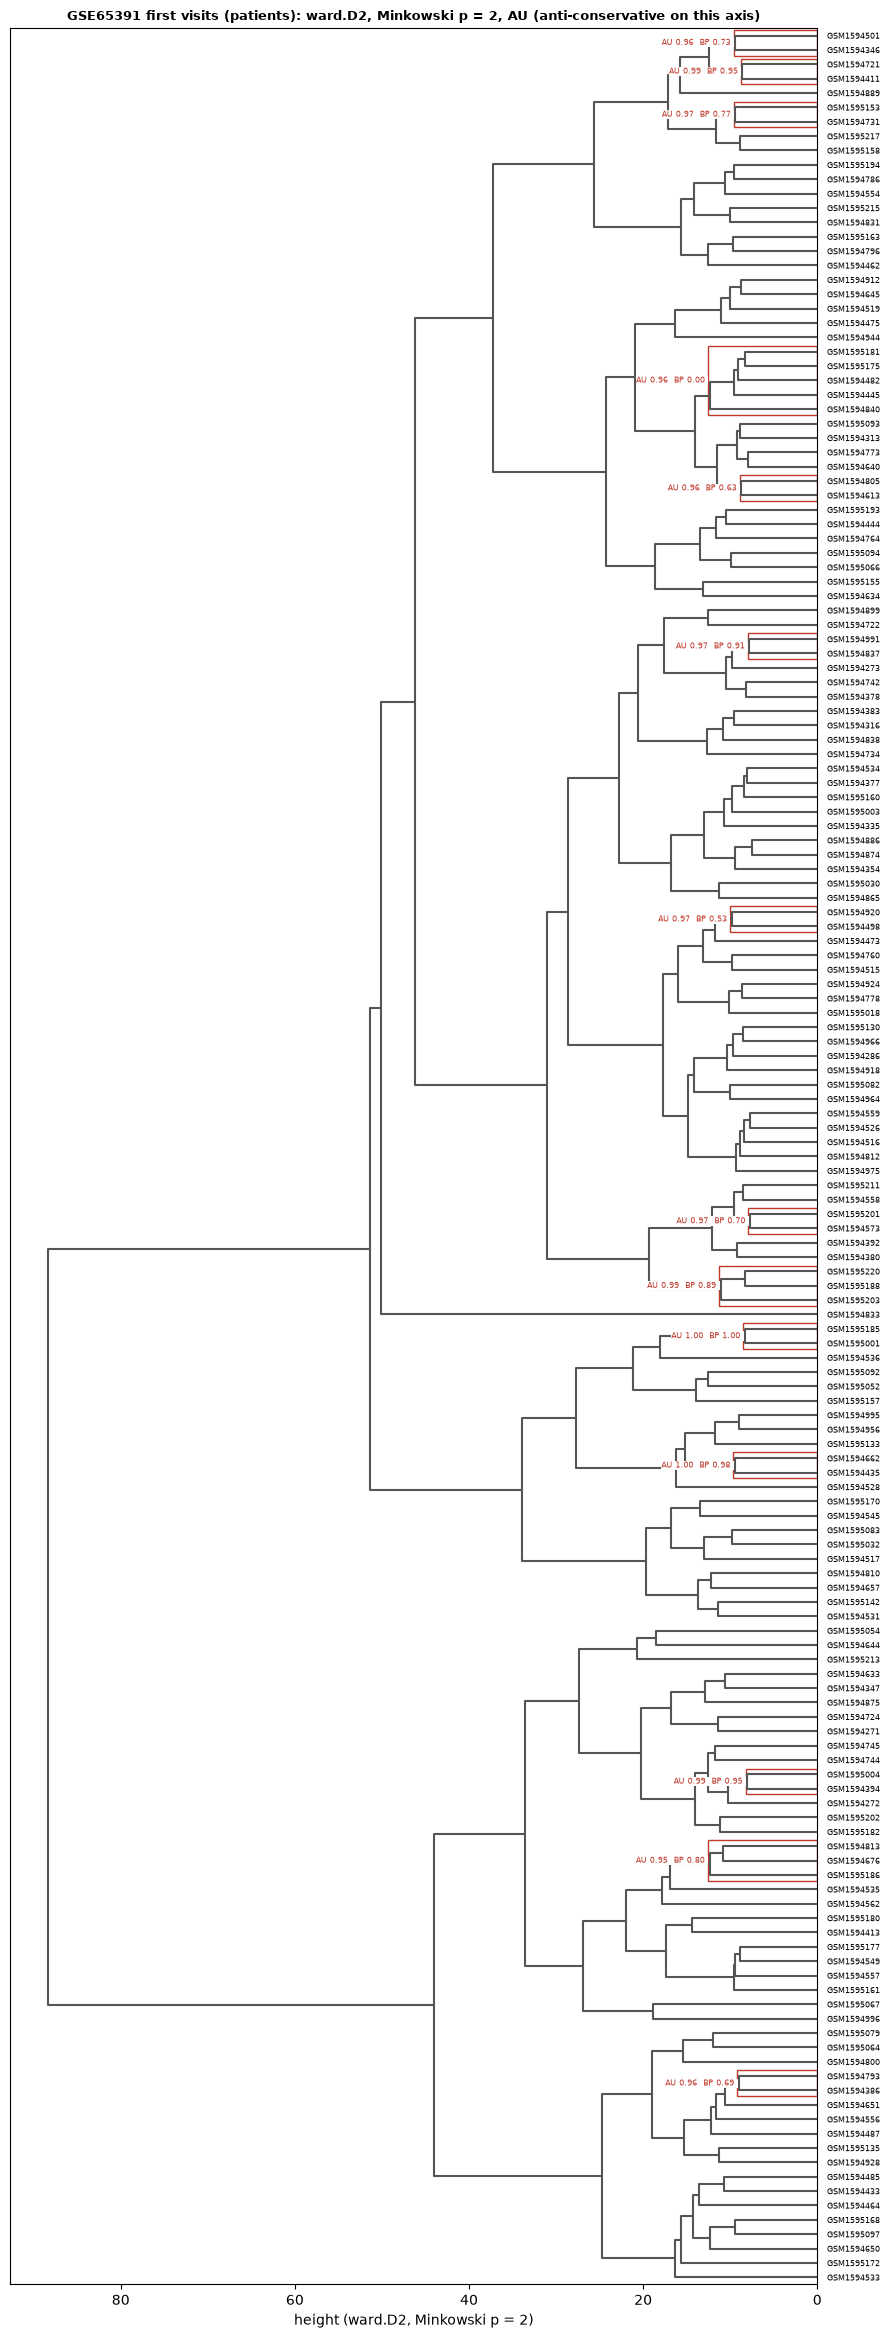

In [5]:
# The pvclust tree with every label shown. Each red box is one pvpick cluster (AU >= 0.95),
# labelled with its AU and BP values (AU: approximately unbiased; BP: ordinary bootstrap).
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.cluster.hierarchy import dendrogram as tree

def pv_figure(res, picked, leaf_text, title, path):
    n = len(res.labels)
    fig, ax = plt.subplots(figsize=(9, max(4, 0.14 * n + 1.5)))
    d = tree(res.linkage, labels=[leaf_text[l] for l in res.labels], orientation="left", ax=ax,
             color_threshold=0, above_threshold_color="#555555", leaf_font_size=6)
    pos = {res.labels[j]: 5 + 10 * k for k, j in enumerate(d["leaves"])}
    for e in picked:
        ys = [pos[m] for m in e["members"]]
        h = res.linkage[e["merge_order"] - 1, 2] * 1.02
        ax.add_patch(Rectangle((0, min(ys) - 4), h, max(ys) - min(ys) + 8, fill=False, edgecolor="#C0392B", lw=1))
        ax.text(h, (min(ys) + max(ys)) / 2, f"AU {e['au']:.2f}  BP {e['bp']:.2f} ", color="#C0392B",
                fontsize=6, ha="right", va="center",
                bbox=dict(facecolor="white", edgecolor="none", pad=0.3))
    ax.set_xlabel("height (ward.D2, Minkowski p = 2)")
    ax.set_title(title, fontsize=9, fontweight="bold")
    fig.tight_layout()
    fig.savefig(path, dpi=300)
    plt.show()

pv_figure(res_p, picked, {s: s for s in res_p.labels}, "GSE65391 first visits (patients): ward.D2, Minkowski p = 2, AU (anti-conservative on this axis)", FIG / "08d_GSE65391_RNA_array_pvclust_patients.png")


**Two-way figure.** Patients as rows, genes as columns, each axis with its pvclust tree and red boxes
on clusters with AU ≥ 0.95; annotation strips for stage and nephritis. The matrix is already z-scored
per gene (notebook 07), so no further scaling is applied. Gene names are shown (up to 200 labels) with
each gene's WGCNA module as a strip.

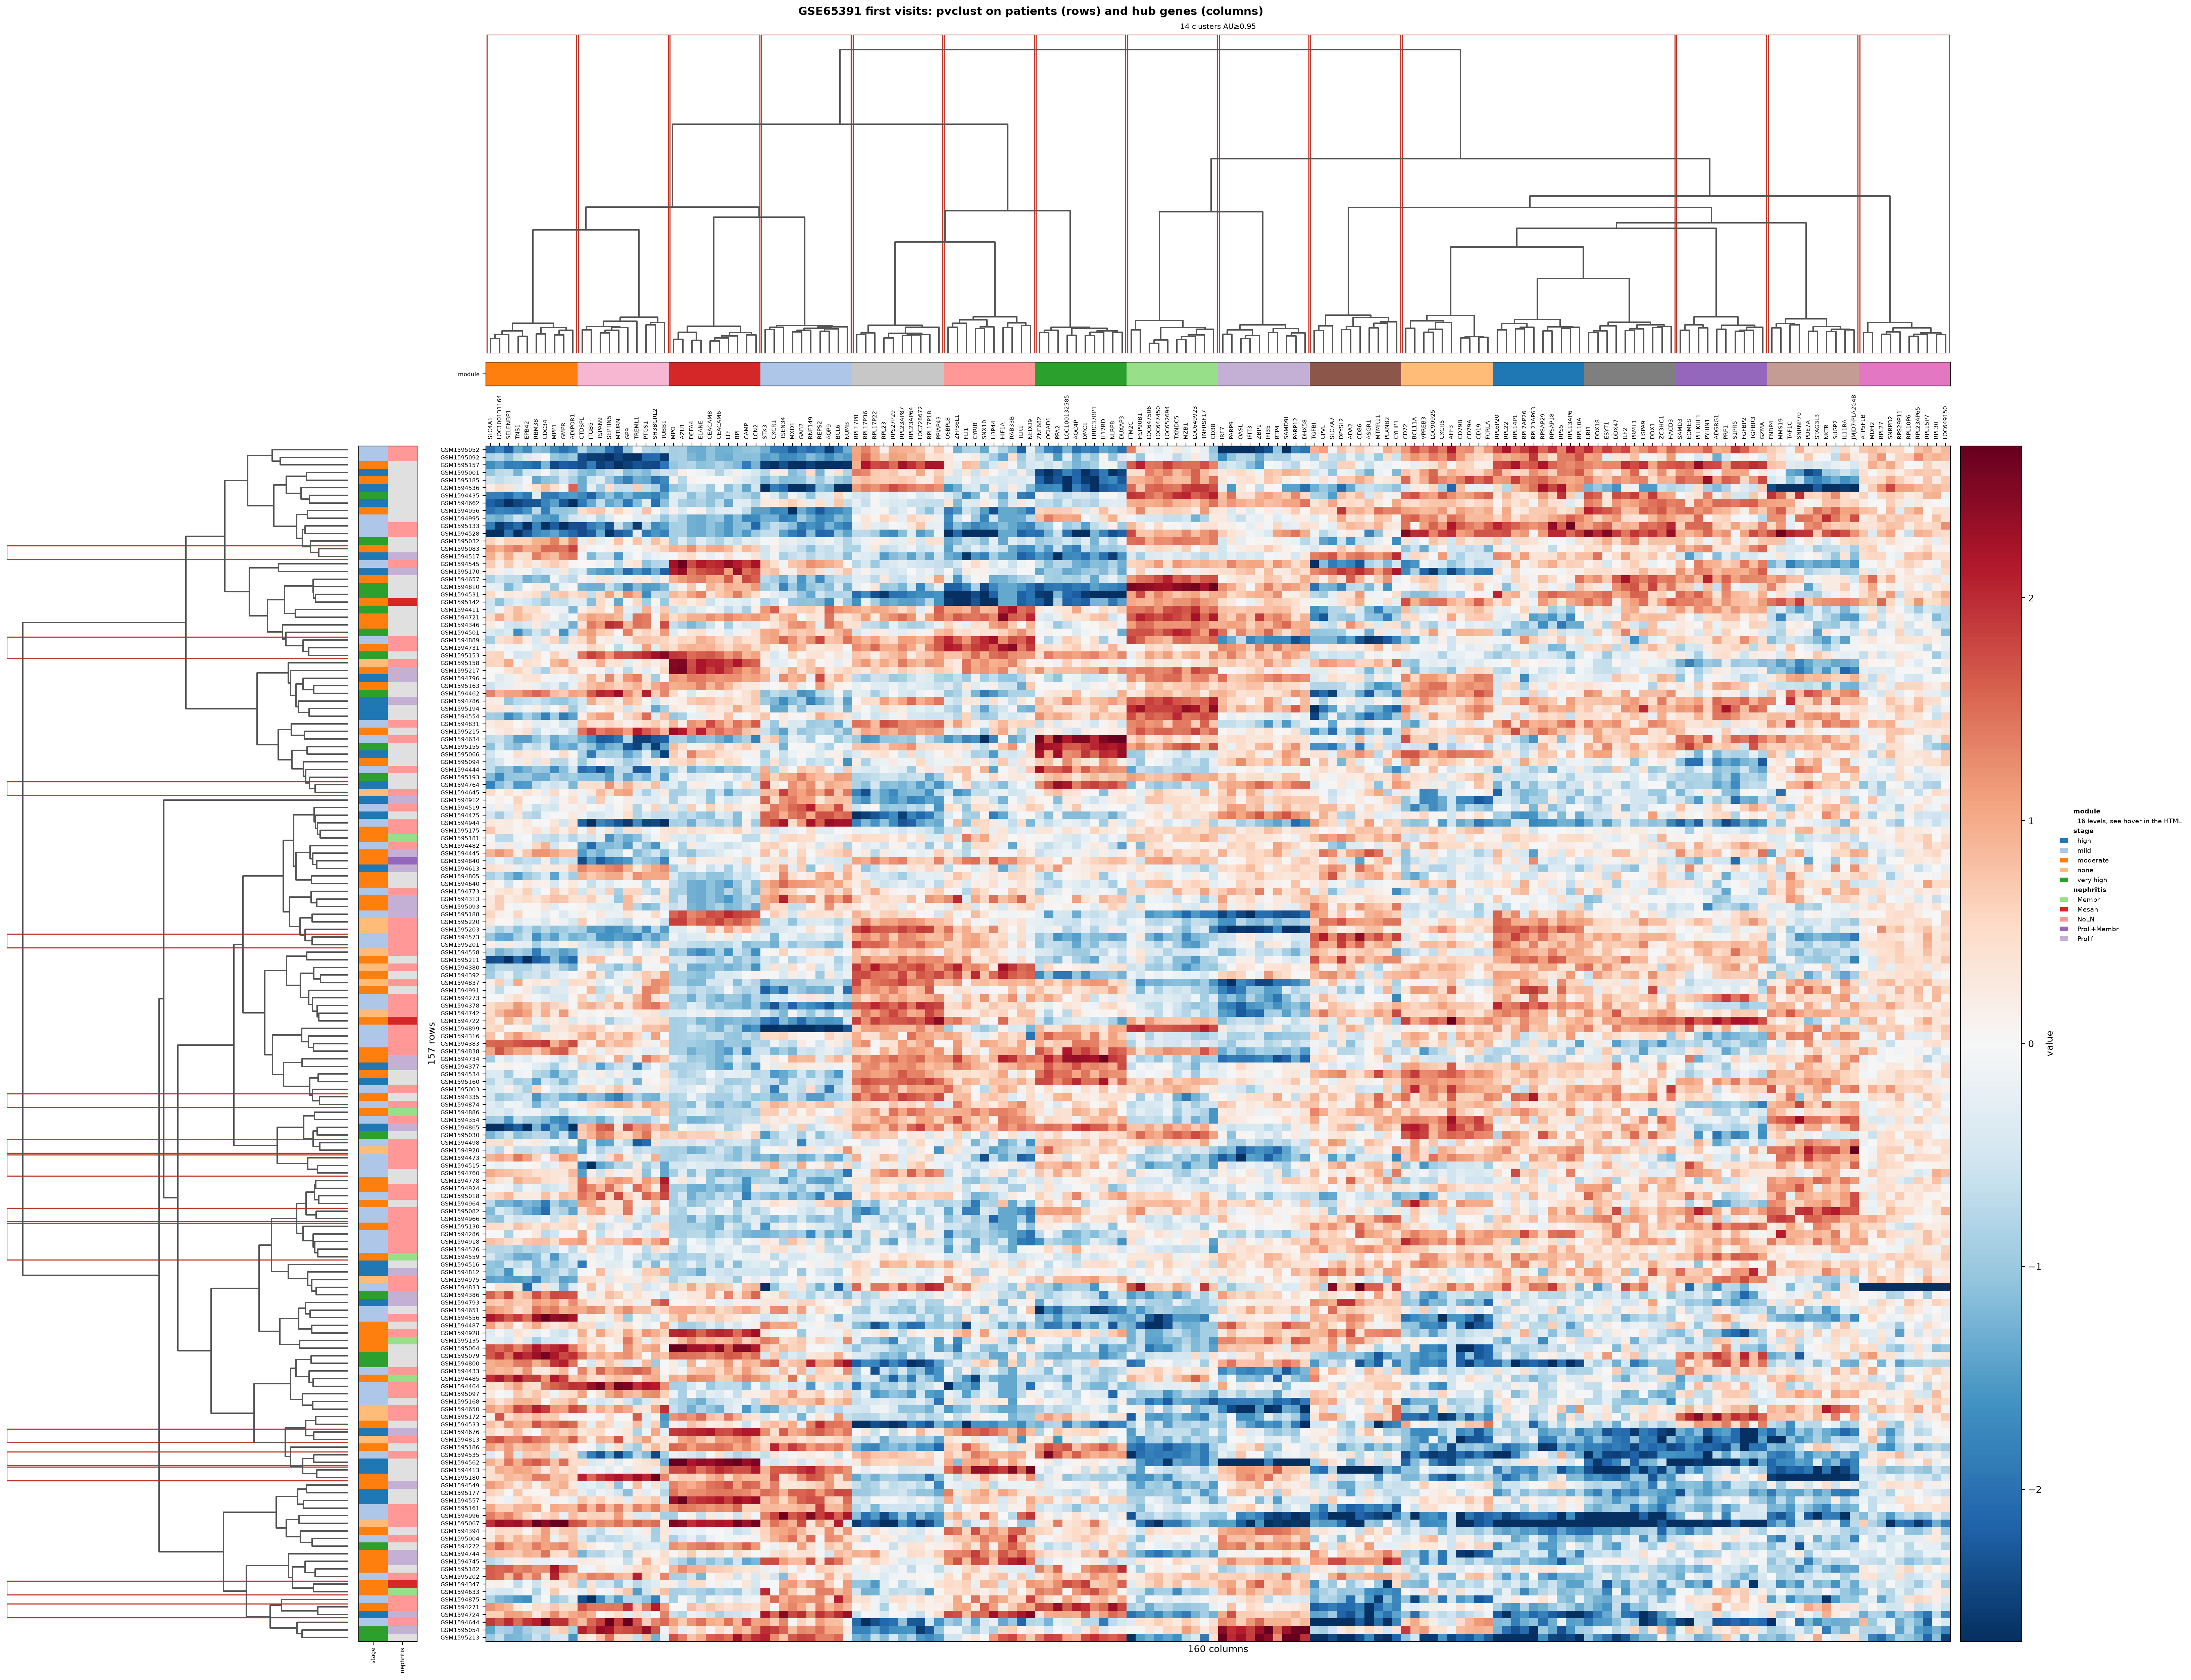

In [6]:
res_g = pickle.load(open(ART / "pvclust_genes.pkl", "rb"))
base2 = str(FIG / "08d_GSE65391_RNA_array_pvclust_two_way")
heatmap(X, base2, row_result=res_p, col_result=res_g, alpha=0.95,
        row_annotations=ann[["stage", "nephritis"]].fillna("NA"), col_annotations=genes[["module"]],
        z_score=None, max_labels=200,
        title="GSE65391 first visits: pvclust on patients (rows) and hub genes (columns)")
display(Image(base2 + ".png"))